In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("D:/Samad/Data_Analysis-Project/Travclan-Hotel-Booking-Project/TA-1/Hotel_bookings_final.csv")

In [3]:
df.shape

(30000, 24)

In [4]:
df.head(4)

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non-null  object 
 16  refu

In [6]:
df.describe()

,customer_id,property_id,star_rating,num_rooms_booked,booking_value,costprice,markup,selling_price,refund_amount,cashback,coupon_redeem
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,249.721767,3.777533,3.602033,1.352333,25080.525454,22541.494100,6963.32440,29504.818500,320.938376,3.831534,4.134988
std,145.484836,2.081471,0.860241,0.574403,11587.369335,9259.520787,2860.10657,12119.627338,339.635396,4.783590,10.846221
min,1.000000,1.000000,2.000000,1.000000,1279.770000,3822.000000,1181.00000,5003.000000,0.000000,0.000000,-3.532183
25%,123.000000,1.000000,3.000000,1.000000,15922.712500,15088.750000,4661.75000,19750.500000,0.000000,0.000000,0.000000
50%,248.000000,3.000000,4.000000,1.000000,24736.145000,22731.000000,7021.50000,29752.500000,221.141185,1.030180,0.000000
75%,376.000000,5.000000,4.000000,2.000000,33570.000000,30427.000000,9399.00000,39826.000000,594.624344,7.378533,0.000000
max,499.000000,7.000000,5.000000,3.000000,67764.460000,38200.000000,11800.00000,50000.000000,1462.725105,21.268013,89.644917


In [7]:
df.isnull().sum()

customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked         0
stay_type                0
booking_channel          0
booking_value            0
costprice                0
markup                   0
selling_price            0
payment_method           0
refund_status            0
refund_amount            0
channel_of_booking       0
booking_status           0
travel_date              0
cashback                 0
coupon_redeem            0
Coupon USed?             0
dtype: int64

In [8]:
#df=df.dropna() it shouldnt be used otherwise it will cause MNAR {MISSING NOT A RANDOM} error, 
# because for this dataset those missing values are not data quality issue, they represent business 

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['booking_date']=pd.to_datetime(df['booking_date'])
df['check_in_date']=pd.to_datetime(df['check_in_date'])
df['check_out_date']=pd.to_datetime(df['check_out_date'])

In [11]:
(df['booking_date']).dtypes

dtype('<M8[ns]')

In [12]:
df['month']=df['booking_date'].dt.month_name()

In [13]:
df['month'].max()

'September'

In [14]:
total_bookings=len(df)
print(total_bookings)

30000


In [15]:
df['is_cancelled']=np.where(
    df['booking_status']=='Cancelled',1,0)

In [16]:
df['is_cancelled'].sum()

np.int64(6070)

In [17]:
df.columns


Index(['customer_id', 'property_id', 'city', 'star_rating', 'booking_date',
       'check_in_date', 'check_out_date', 'room_type', 'num_rooms_booked',
       'stay_type', 'booking_channel', 'booking_value', 'costprice', 'markup',
       'selling_price', 'payment_method', 'refund_status', 'refund_amount',
       'channel_of_booking', 'booking_status', 'travel_date', 'cashback',
       'coupon_redeem', 'Coupon USed?', 'month', 'is_cancelled'],
      dtype='object')

Overall Calculation Rate

In [18]:
cancel_rate=(
    df[df['booking_status']=='Cancelled'].shape[0]/df.shape[0]
)*100
print(cancel_rate)

20.233333333333334


Booking Pattern by channel

In [19]:
df['booking_channel'].value_counts()

booking_channel
Web             15001
Mobile App      12009
Travel Agent     2990
Name: count, dtype: int64

In [20]:
df['booking_channel'].value_counts(normalize=True)*100

booking_channel
Web             50.003333
Mobile App      40.030000
Travel Agent     9.966667
Name: proportion, dtype: float64

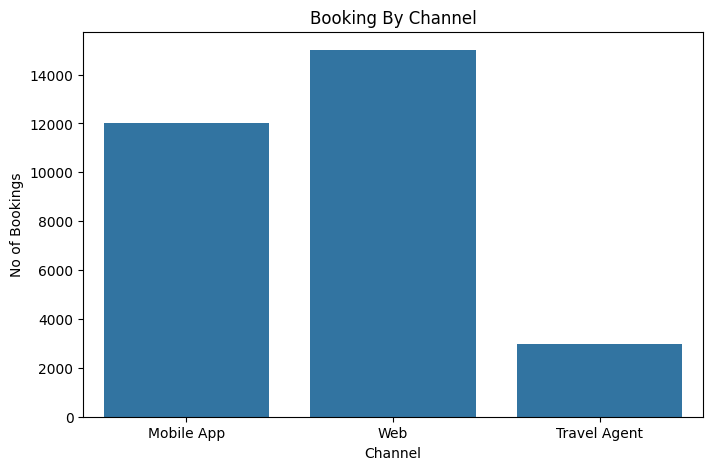

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='booking_channel')
plt.title("Booking By Channel")
plt.xlabel('Channel')
plt.ylabel('No of Bookings')
plt.show()

Booking Status DISTRIBUTION

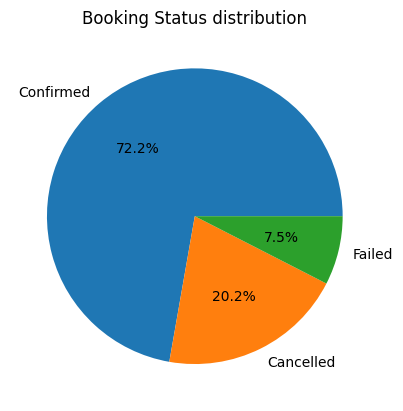

In [22]:
df['booking_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%')
plt.ylabel("")
plt.title('Booking Status distribution')
plt.show()

    Cancellation Rate by channel

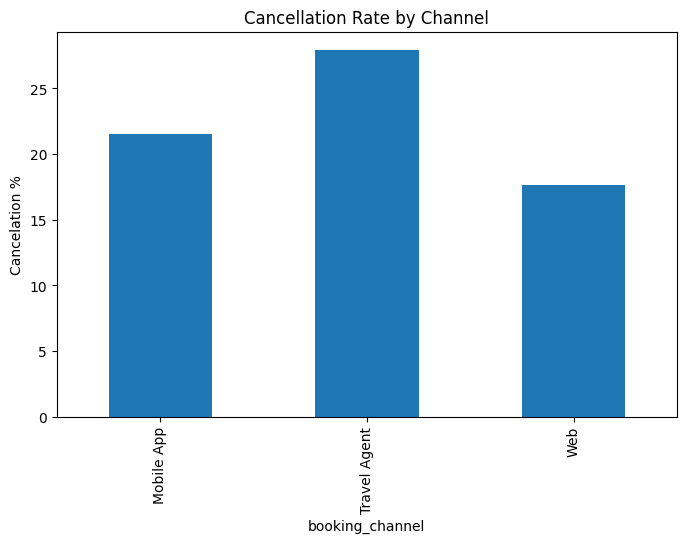

In [23]:
ch_cancel=pd.crosstab(
    df['booking_channel'],
    df['booking_status'],
    normalize='index'
)*100
ch_cancel['Cancelled'].plot(
    kind='bar',
    figsize=(8,5)
)
plt.ylabel('Cancelation %')
plt.title('Cancellation Rate by Channel')
plt.show()

CANCELLATION RATE BY ROOM TYPE

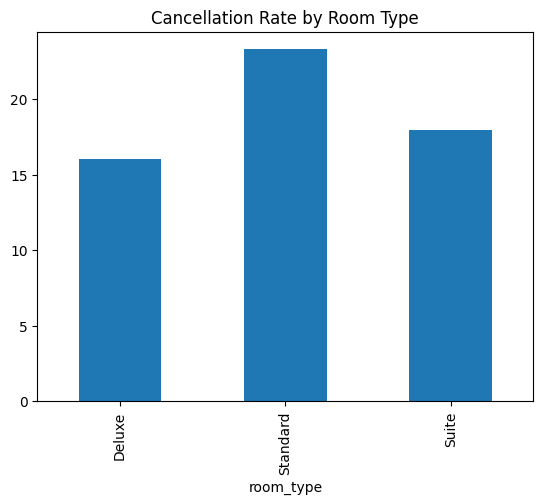

In [24]:
r_cancel=pd.crosstab(
    df['room_type'],
    df['booking_status'],
    normalize='index'
)*100
r_cancel['Cancelled'].plot(
    kind='bar')
plt.title('Cancellation Rate by Room Type')
plt.show()

r_cancel=pd.crosstab(
    df['room_type'],
    df['booking_status'],
    normalize='index'
)*100
r_cancel['Cancelled'].plot(
    kind='bar'
)
plt.title('Cancellation Rate by Room Type')
plt.show()

Revenue By Channel

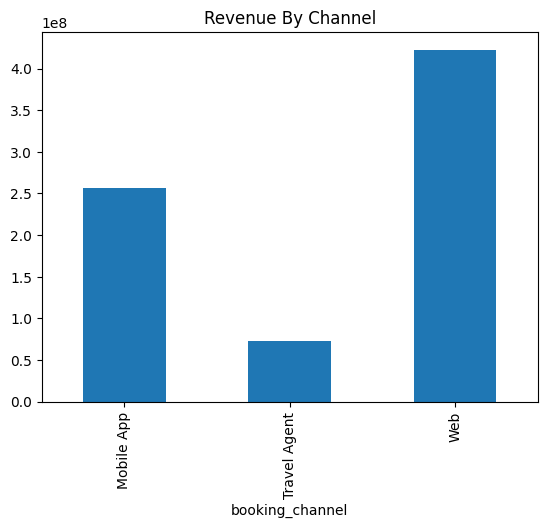

In [25]:
df.groupby('booking_channel')['booking_value'].sum().plot(
    kind='bar')

plt.title('Revenue By Channel')
plt.show()

Monthly Booking Trend

In [26]:
pd.crosstab(
    df['booking_channel'],
    df['booking_status'],
    normalize='index'
)*100

booking_status,Cancelled,Confirmed,Failed
booking_channel,,,
Mobile App,21.558831,67.541011,10.900158
Travel Agent,27.926421,66.187291,5.886288
Web,17.638824,77.208186,5.152990


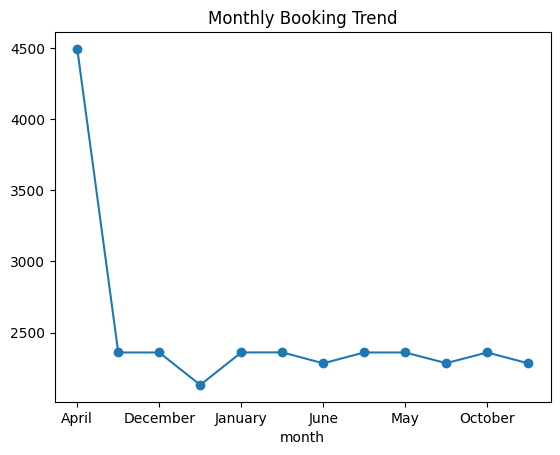

In [27]:
df.groupby('month').size().plot(
    kind='line',
    marker='o')

plt.title('Monthly Booking Trend')
plt.show()

Monthly Revenue Trend

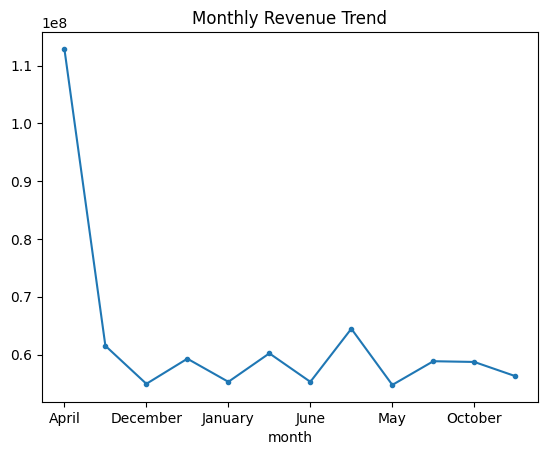

In [28]:
df.groupby('month')['booking_value'].sum().plot(
    kind='line',
    marker='.')

plt.title('Monthly Revenue Trend')
plt.show()

Star Rating BY Cancellation Rate

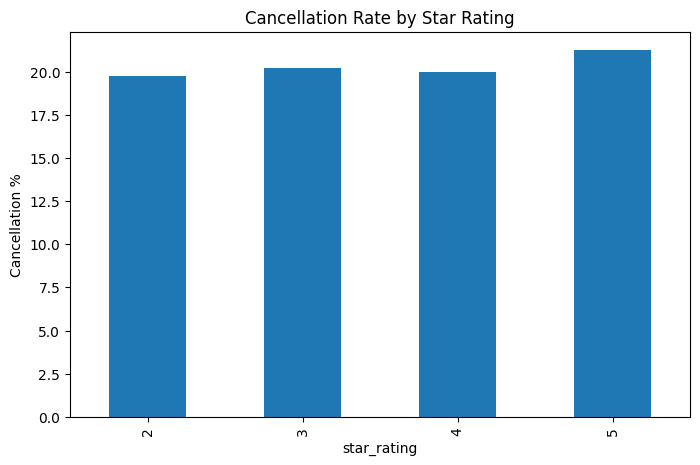

In [29]:
star_cancel=pd.crosstab(
    df['star_rating'],
    df['booking_status'],
    normalize='index'
)*100
star_cancel['Cancelled'].plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Cancellation Rate by Star Rating')
plt.ylabel('Cancellation %')
plt.show()

Room Type Analysis

In [30]:
df['room_type'].value_counts()

room_type
Standard    16552
Deluxe      10478
Suite        2970
Name: count, dtype: int64

In [31]:
pd.crosstab(
    df['room_type'],
    df['booking_status'],
    normalize='index'
)*100

booking_status,Cancelled,Confirmed,Failed
room_type,,,
Deluxe,16.024050,76.312273,7.663676
Standard,23.302320,69.188014,7.509667
Suite,17.979798,74.882155,7.138047


Star Rating Analysis

In [32]:
df.groupby('star_rating').agg({
    'booking_value':'mean' })

,booking_value
star_rating,
2,24855.819716
3,25209.567736
4,25010.623536
5,25116.972161


In [33]:
pd.crosstab(
    df['star_rating'],
    df['booking_status'],
    normalize='index'
)*100

booking_status,Cancelled,Confirmed,Failed
star_rating,,,
2,19.766277,72.854758,7.378965
3,20.200765,72.648184,7.151052
4,19.993352,72.112348,7.894299
5,21.259144,71.225892,7.514963


Monthly Trensd

In [34]:
df['booking_date']

0       2024-04-01
1       2024-04-01
2       2024-04-01
3       2024-04-01
4       2024-04-01
           ...    
29995   2025-04-29
29996   2025-04-29
29997   2025-04-29
29998   2025-04-29
29999   2025-04-30
Name: booking_date, Length: 30000, dtype: datetime64[ns]

extrating month

In [35]:
df['month']=df['booking_date'].dt.month_name()

In [52]:
df.groupby('month').size()

month
April        4494
August       2360
December     2360
February     2132
January      2360
July         2361
June         2284
March        2360
May          2360
November     2285
October      2360
September    2284
dtype: int64

In [45]:
df.groupby('month')['booking_value'].sum()

month
April        1.128735e+08
August       6.151278e+07
December     5.493369e+07
February     5.928334e+07
January      5.528121e+07
July         6.020926e+07
June         5.527916e+07
March        6.446651e+07
May          5.474528e+07
November     5.884617e+07
October      5.871826e+07
September    5.626658e+07
Name: booking_value, dtype: float64

Stay Length Analysis

In [38]:
df['stay_length']= (
    df['check_out_date']-
    df['check_in_date']).dt.days

In [46]:
df.groupby('stay_type')['stay_length'].mean()

stay_type
Business    4.028428
Leisure     3.992544
Name: stay_length, dtype: float64

In [40]:
df.groupby('month')['stay_length'].mean()

month
April        4.044145
August       4.003648
December     3.975065
February     4.057159
January      4.061193
July         4.031151
June         4.023467
March        3.888542
May          3.986486
November     3.986849
October      3.986444
September    4.007576
Name: stay_length, dtype: float64

Revenue Analysis

In [41]:
df.groupby('booking_channel')['booking_value'].agg(
    ['count','sum','mean']
)

,count,sum,mean
booking_channel,,,
Mobile App,12009,2.564076e+08,21351.285716
Travel Agent,2990,7.311738e+07,24453.972990
Web,15001,4.228908e+08,28190.840225


In [42]:
pd.pivot_table(
    df,
    values='booking_value',
    index='booking_channel',
    columns='booking_status',
    aggfunc='count'
)

booking_status,Cancelled,Confirmed,Failed
booking_channel,,,
Mobile App,2589,8111,1309
Travel Agent,835,1979,176
Web,2646,11582,773


Exe Summary:

Total Booking: 30,000
Cancellation Rate: 20.2%
Standard rooms are the most cancellation-Prone room category
Web Channel generaetes highest avg booking value
Seasonal peaks are obsereved in booking value adn booking volume

RCA-Root Cause Analysis

Finding1 

Travel agent channel has the highest Cancellation with 27.9% cancellation rate compared to 21,6% for mobilel app and 17.6% for web booking 

Root Cause

Customer using Intermediates have lower the commitment and more alternatives.

Recommendation

Introduce advance payment requirement and reminder campaigns

Finding 2

Standard Rooms have thre highest Cancellation Rate 

Root Cause:
Price sensitive customers can easily switch to competetive offer

Recommendation:
Offer loyality discount and limited time upgrades

Finding 3

Web Channels generates high avg booking value

Root Cause :
Direct Customer exhibtss stronger purchase intent

Recommendation:
Invest More in Direct Booking Campaigns